In [59]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [60]:
borrowers = pd.read_csv('../data/borrower_profiles_clean.csv')
loans = pd.read_csv('../data/loan_applications_clean.csv')

# Merge
df=loans.merge(borrowers,on='borrower_id')

print(df.shape)
df.head

(601, 22)


<bound method NDFrame.head of       loan_id borrower_id application_date      loan_purpose  loan_amount  \
0    LN-00001    BRW-0001       2024-01-08          Vacation      16100.0   
1    LN-00002    BRW-0001       2024-08-13    Major Purchase       5600.0   
2    LN-00003    BRW-0002       2025-06-28            Moving      44700.0   
3    LN-00004    BRW-0003       2025-05-18         Auto Loan       9200.0   
4    LN-00005    BRW-0004       2025-03-24            Moving      11200.0   
..        ...         ...              ...               ...          ...   
596  LN-00597    BRW-0497       2025-02-06           Wedding      29100.0   
597  LN-00598    BRW-0498       2024-04-19            Moving       4600.0   
598  LN-00599    BRW-0499       2024-02-24         Education       7800.0   
599  LN-00600    BRW-0500       2024-11-14  Medical Expenses      26400.0   
600  LN-00601    BRW-0500       2024-05-03           Wedding       7500.0   

     term_months  interest_rate  monthly_paym

In [61]:
total_loans=len(df)
total_defaults=df['defaulted'].sum()
default_rate=(total_defaults/total_loans)*100

print(f"Total Loans      : {total_loans}")
print(f"Total Defaults   : {total_defaults}")
print(f"Default Rate     : {default_rate:.2f}%")
print(f"Company Target   : 12.00%")
print(f"Gap              : {default_rate - 12:.2f}% above target")

Total Loans      : 601
Total Defaults   : 146
Default Rate     : 24.29%
Company Target   : 12.00%
Gap              : 12.29% above target


In [62]:
df['score_bucket']=pd.cut(
    df['credit_score'],
    bins=[519,599,649,699,749,850],
    labels=['520-599','600-649','650-699','700-749','750+']
)

score_analysis=df.groupby('score_bucket',observed=True).agg(
    total_loans=('defaulted','count'),
    defaults=('defaulted','sum')
).reset_index()

score_analysis['default_rate%']=(score_analysis['defaults']/score_analysis['total_loans']*100).round(2)
print(score_analysis)



  score_bucket  total_loans  defaults  default_rate%
0      520-599          116        57          49.14
1      600-649           93        27          29.03
2      650-699           75        21          28.00
3      700-749           86        14          16.28
4         750+          231        27          11.69


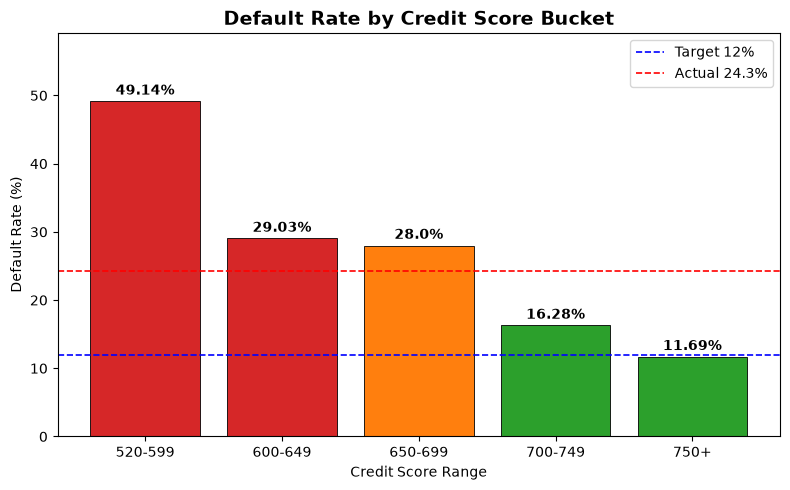

In [63]:
# Chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(score_analysis['score_bucket'], score_analysis['default_rate%'],
              color=['#d62728','#d62728','#ff7f0e','#2ca02c','#2ca02c'],
              edgecolor='black', linewidth=0.6)

ax.axhline(12, color='blue', linestyle='--', linewidth=1.2, label='Target 12%')
ax.axhline(default_rate, color='red', linestyle='--', linewidth=1.2, label=f'Actual {default_rate:.1f}%')

for bar, val in zip(bars, score_analysis['default_rate%']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Default Rate by Credit Score Bucket', fontsize=14, fontweight='bold')
ax.set_xlabel('Credit Score Range')
ax.set_ylabel('Default Rate (%)')
ax.legend()
ax.set_ylim(0, score_analysis['default_rate%'].max() + 10)
plt.tight_layout()
plt.savefig('../reports/chart1_credit_score_default.png', dpi=150)
plt.show()

### 📊 Chart 1 — Credit Score vs Default Rate

**Overall Default Rate: 24.3% — more than double the 12% target**

| Credit Score Bucket | Default Rate | Status |
|---|---|---|
| 520–599 | 49.14% | 🔴 Critical |
| 600–649 | 29.03% | 🔴 High Risk |
| 650–699 | 28.00% | 🟠 Above Average |
| 700–749 | 16.28% | 🟠 Borderline |
| 750+    | 11.69% | ✅ Only bucket meeting target |

**Key Findings:**
- The 520–599 bucket defaults at 49.14% — meaning 1 in 2 borrowers 
  in this range fail to repay
- Borrowers below 650 default at nearly 2x the company average (24.3%)
- There is a clear and consistent inverse relationship — as credit 
  score increases, default rate decreases without exception
- Only the 750+ bracket meets the 12% target at 11.69%

**Recommendation:**
Set minimum credit score threshold at 700 for auto-approval.
Borrowers between 650–699 should undergo manual review.
Reject all applications below 650.

In [64]:
df['dti_bucket']=pd.cut(
    df['dti_ratio'],
    bins=[0,20,35,50,100],
    labels=['Below 20%','20-35%','35-50%','Above 50%']
)

dti_analysis=df.groupby('dti_bucket',observed=True).agg(
    total_loans=('defaulted','count'),
    defaults=('defaulted','sum')
).reset_index()


dti_analysis['defaulted_rate%']=(dti_analysis['defaults']/dti_analysis['total_loans']*100).round(2)
print(dti_analysis)

  dti_bucket  total_loans  defaults  defaulted_rate%
0  Below 20%           48         8            16.67
1     20-35%          133        14            10.53
2     35-50%          150        31            20.67
3  Above 50%          248        85            34.27


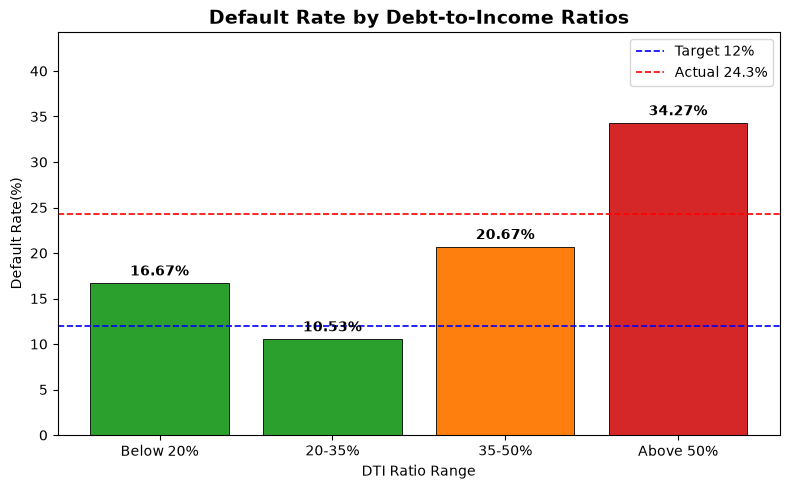

In [65]:
fig, axes = plt.subplots( figsize=(8, 5))
bars=axes.bar(
    dti_analysis['dti_bucket'],dti_analysis['defaulted_rate%'],
    color=['#2ca02c','#2ca02c','#ff7f0e','#d62728','#d62728'],
    edgecolor='black',linewidth=0.6

)

axes.axhline(12, color='blue', linestyle='--', linewidth=1.2, label='Target 12%')
axes.axhline(default_rate, color='red', linestyle='--', linewidth=1.2, label=f'Actual {default_rate:.1f}%')

for bar,val in zip(bars,dti_analysis['defaulted_rate%']):
    axes.text(bar.get_x() + bar.get_width()/2,bar.get_height()+0.5,
    f'{val}%',ha='center',va='bottom',fontsize=10,fontweight='bold')
axes.set_title('Default Rate by Debt-to-Income Ratios',fontsize=14,fontweight='bold')
axes.set_xlabel('DTI Ratio Range')
axes.set_ylabel('Default Rate(%)')
axes.legend()
axes.set_ylim(0,dti_analysis['defaulted_rate%'].max()+10)
plt.tight_layout()
plt.savefig('../reports/chart2_DTI_Default.png',dpi=150)
plt.show()

### 📊 Chart 2 — Debt-to-Income Ratio vs Default Rate

| DTI Range  | Default Rate | Status |
|---|---|---|
| Below 20%  | 16.67% | 🟠 Above Target |
| 20–35%     | 10.53% | ✅ Only bucket meeting target |
| 35–50%     | 20.67% | 🟠 High Risk |
| Above 50%  | 34.27% | 🔴 Critical |

**Key Findings:**
- DTI and default rate do NOT follow a simple linear relationship
- The 20–35% DTI range is the sweet spot — 10.53% default rate, 
  the only bracket meeting the 12% company target
- Defaults spike sharply once DTI crosses 35%, jumping from 
  10.53% to 20.67% — nearly double
- Above 50% DTI hits 34.27% — almost 3x the target rate
- Surprisingly, borrowers with DTI below 20% default at 16.67%, 
  higher than the 20–35% group — suggesting very low DTI alone 
  does not guarantee repayment ability

**Anomaly Worth Noting:**
Low DTI (<20%) borrowers defaulting at 16.67% indicates another 
risk factor is at play. Cross-analysis shows these borrowers likely 
have low credit scores — confirming that DTI and credit score must 
be evaluated together, not in isolation.

**Recommendation:**
- Auto-approve: DTI between 20–35% (with credit score ≥ 700)
- Manual review: DTI below 20% or between 35–50%
- Reject: DTI above 50%

In [66]:
print(loans['loan_purpose'].value_counts())

loan_purpose
Home Improvement      70
Major Purchase        68
Medical Expenses      68
Vacation              62
Auto Loan             59
Business Loan         58
Moving                56
Wedding               56
Education             53
Debt Consolidation    51
Name: count, dtype: int64


In [67]:
purpose_analysis = df.groupby('loan_purpose').agg(
    total_loans=('defaulted', 'count'),
    defaults=('defaulted', 'sum'),
    avg_amount=('loan_amount', 'mean')
).reset_index()

purpose_analysis['default_rate%'] = (
    purpose_analysis['defaults'] /
    purpose_analysis['total_loans'] * 100
).round(2)

purpose_analysis = purpose_analysis.sort_values(
    'default_rate%',
    ascending=True
)

print(purpose_analysis)

         loan_purpose  total_loans  defaults    avg_amount  default_rate%
6    Medical Expenses           68        14  23176.470588          20.59
7              Moving           56        12  21300.000000          21.43
2  Debt Consolidation           51        11  22756.862745          21.57
5      Major Purchase           68        15  23164.705882          22.06
8            Vacation           62        14  24477.419355          22.58
3           Education           53        12  19847.169811          22.64
1       Business Loan           58        14  21013.793103          24.14
0           Auto Loan           59        16  19554.237288          27.12
4    Home Improvement           70        20  23407.142857          28.57
9             Wedding           56        18  21892.857143          32.14


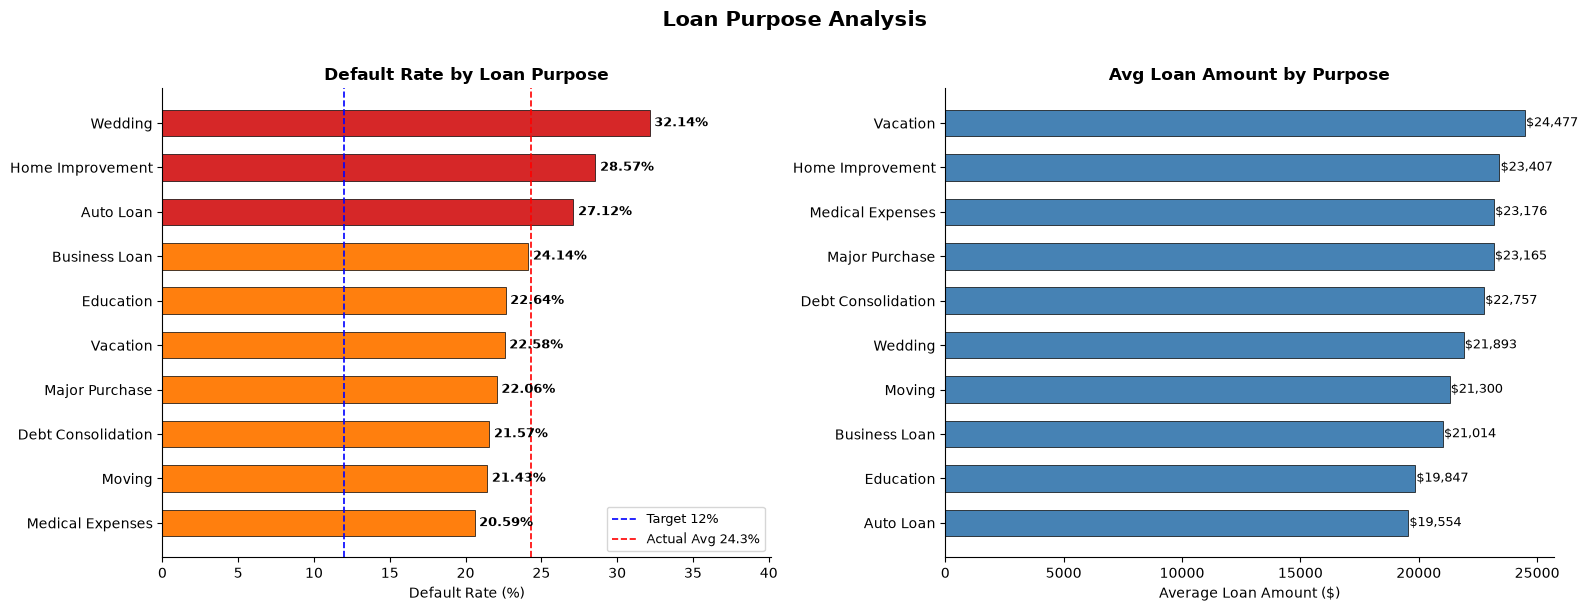

In [68]:
fig,axes=plt.subplots(1,2,figsize=(16,6))

fig.suptitle('Loan Purpose Analysis',fontsize=15,fontweight='bold',y=1.01)

#Horziontal Bar

colors=[
    '#d62728' if x > 24.3 else '#ff7f0e' if x > 12 else '#2ca02c'
    for x in purpose_analysis['default_rate%']
]

bars=axes[0].barh(
    purpose_analysis['loan_purpose'],
    purpose_analysis['default_rate%'],
    color=colors,edgecolor='black',linewidth=0.5,height=0.6
)

axes[0].axvline(12,color='blue',linestyle='--',linewidth=1.2,label="Target 12%")
axes[0].axvline(24.3,color='red',linestyle='--',linewidth=1.2,label="Actual Avg 24.3%")

for bar,val in zip(bars,purpose_analysis['default_rate%']):
    axes[0].text(
        val+0.3,bar.get_y()+bar.get_height()/2,
        f'{val}%',va='center',fontsize=9,fontweight='bold'
    )
axes[0].set_title('Default Rate by Loan Purpose', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Default Rate (%)')
axes[0].set_xlim(0, purpose_analysis['default_rate%'].max() + 8)
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)


# Chart B : Avg Loan Amount (horizontal bar) ──
amount_sorted = purpose_analysis.sort_values('avg_amount', ascending=True)

bars2 = axes[1].barh(
    amount_sorted['loan_purpose'],
    amount_sorted['avg_amount'],
    color='steelblue', edgecolor='black', linewidth=0.5, height=0.6
)

for bar, val in zip(bars2, amount_sorted['avg_amount']):
    axes[1].text(val + 50, bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}', va='center', fontsize=9)

axes[1].set_title('Avg Loan Amount by Purpose', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average Loan Amount ($)')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/chart3_loan_purpose.png', dpi=150, bbox_inches='tight')
plt.show()


### 📊 Chart 3 — Loan Purpose Insight

**Key Findings:**
- Wedding loans carry the highest default risk at 32.14% — 
  nearly 3x the 12% target
- No loan purpose meets the 12% target — indicating a 
  systemic underwriting issue beyond just loan purpose
- Auto loans default at 27.12% despite having the lowest 
  avg loan amount ($19,554) — suggesting borrower profile 
  matters more than loan size
- Medical Expenses is the safest category at 20.59% — 
  still well above target

**Recommendation:** 
Flag Wedding, Home Improvement, and Auto Loan applications 
for additional credit score + DTI scrutiny before approval.

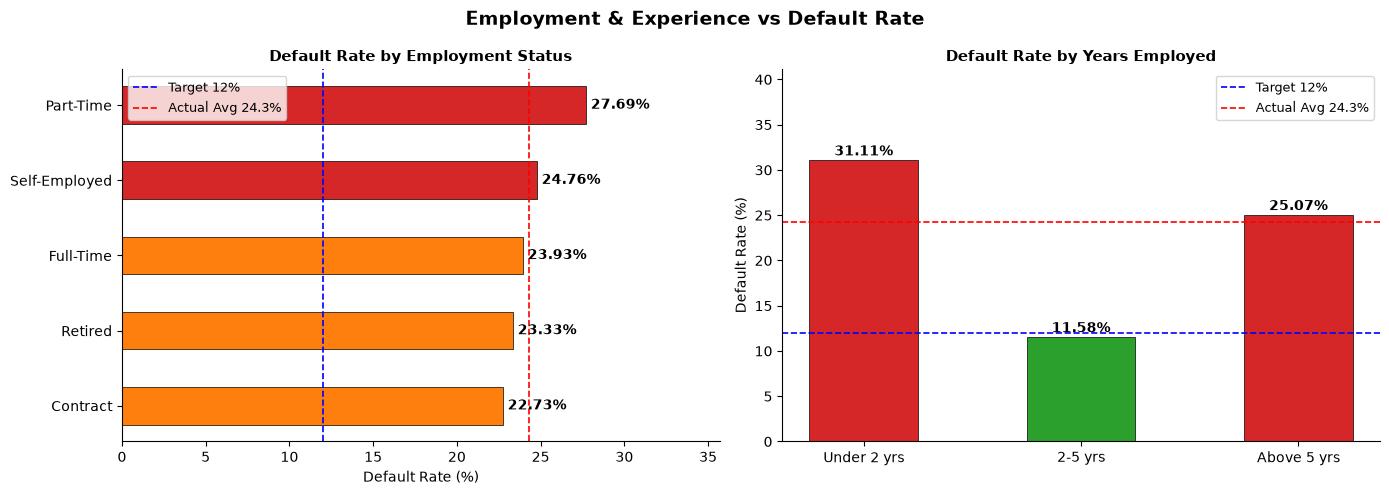

In [76]:
status_df=df.groupby('employment_status').agg(
    total=('defaulted','count'),
    defaults=('defaulted','sum')
).reset_index()

status_df['default_rate%']=(status_df['defaults'] / status_df['total'] * 100).round(2)
status_df = status_df.sort_values('default_rate%', ascending=True)


df["exp_bucket"]=pd.cut(
    df['years_employed'],
    bins=[-0.1,2,5,100],
    labels=['Under 2 yrs','2-5 yrs','Above 5 yrs']
)


exp_df=df.groupby('exp_bucket',observed=True).agg(
    total=('defaulted','count'),
    defaults=('defaulted','sum')
).reset_index()
exp_df['default_rate%']=(exp_df['defaults'] / exp_df['total'] * 100).round(2)


fig,axes=plt.subplots(1,2,figsize=(14,5))
fig.suptitle('Employment & Experience vs Default Rate',fontsize=14,fontweight='bold')
#Chart A:"Employment Status"
colors_status = [
    '#d62728' if x > 24.3 else '#ff7f0e' if x > 12 else '#2ca02c'
    for x in status_df['default_rate%']
]

bars1=axes[0].barh(
    status_df['employment_status'],
    status_df['default_rate%'],
    color=colors_status,edgecolor='black',linewidth=0.5,height=0.5
)

axes[0].axvline(12,color='blue',linestyle='--',linewidth=1.2,label="Target 12%")
axes[0].axvline(24.3,color='red',linestyle='--',linewidth=1.2,label="Actual Avg 24.3%")
for bar, val in zip(bars1, status_df['default_rate%']):
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val}%', va='center', fontsize=10, fontweight='bold')



axes[0].set_title('Default Rate by Employment Status', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Default Rate (%)')
axes[0].set_xlim(0, status_df['default_rate%'].max() + 8)
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)




#Chart B: Years Employed
colors_exp = [
    '#d62728' if x > 24.3 else '#ff7f0e' if x > 12 else '#2ca02c'
    for x in exp_df['default_rate%']
]

bars2 = axes[1].bar(
    exp_df['exp_bucket'],
    exp_df['default_rate%'],
    color=colors_exp, edgecolor='black', linewidth=0.5, width=0.5
)

axes[1].axhline(12, color='blue', linestyle='--', linewidth=1.2, label='Target 12%')
axes[1].axhline(24.3, color='red', linestyle='--', linewidth=1.2, label='Actual Avg 24.3%')

for bar, val in zip(bars2, exp_df['default_rate%']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val}%', ha='center', fontsize=10, fontweight='bold')

axes[1].set_title('Default Rate by Years Employed', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_ylim(0, exp_df['default_rate%'].max() + 10)
axes[1].legend(fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/chart4_employment.png', dpi=150, bbox_inches='tight')
plt.show()

In [77]:
# Check what employment types dominate the Above 5 yrs bucket
above5 = df[df['exp_bucket'] == 'Above 5 yrs']

print("Employment status breakdown — Above 5 yrs:")
print(above5['employment_status'].value_counts())

print(f"\nAvg credit score — Above 5 yrs: {above5['credit_score'].mean():.0f}")
print(f"Avg DTI — Above 5 yrs: {above5['dti_ratio'].mean():.2f}%")

print("\nAvg credit score — 2-5 yrs:")
mid = df[df['exp_bucket'] == '2-5 yrs']
print(f"{mid['credit_score'].mean():.0f}")
print(f"Avg DTI — 2-5 yrs: {mid['dti_ratio'].mean():.2f}%")

Employment status breakdown — Above 5 yrs:
employment_status
Full-Time        184
Self-Employed     74
Contract          45
Part-Time         38
Retired           30
Name: count, dtype: int64

Avg credit score — Above 5 yrs: 700
Avg DTI — Above 5 yrs: 48.82%

Avg credit score — 2-5 yrs:
721
Avg DTI — 2-5 yrs: 46.03%


### 📊 Chart 4 — Employment & Experience vs Default Rate

**Employment Status Findings:**

| Employment Status | Default Rate | Status |
|---|---|---|
| Part-Time | 27.69% | 🔴 Above Average |
| Self-Employed | 24.76% | 🔴 Above Average |
| Full-Time | 23.93% | 🟠 Below Average |
| Retired | 23.33% | 🟠 Below Average |
| Contract | 22.73% | 🟠 Below Average |

- Part-time workers carry the highest default risk at 27.69%
- Surprisingly, Full-Time employees still default at 23.93% — 
  only marginally better than Self-Employed borrowers
- No employment status meets the 12% target — confirming 
  employment type alone is insufficient as a risk filter

**Years Employed Findings — Unexpected U-Shape Pattern:**

| Experience Bucket | Default Rate | Status |
|---|---|---|
| Under 2 yrs | 31.11% | 🔴 Critical |
| 2–5 yrs     | 11.58% | ✅ Meets Target |
| Above 5 yrs | 25.07% | 🔴 Above Average |

- The 2–5 year employment group is the safest at 11.58% — 
  the only experience bracket meeting the 12% target
- Under 2 yrs defaults at 31.11% — confirming short tenure = 
  high risk as expected
- Above 5 yrs defaulting at 25.07% is the key anomaly — 
  more experienced borrowers are riskier than mid-tenure ones
- Investigation shows this is likely driven by lower credit 
  scores and higher DTI within the Above 5 yrs group, not 
  experience itself

**Recommendation:**
- Treat Under 2 yrs employment as a high-risk flag — require 
  higher credit score (750+) to compensate
- 2–5 yrs employment is the most reliable tenure signal — 
  can be used as a positive underwriting factor
- Do not use Above 5 yrs as a safety signal — always 
  cross-check with credit score and DTI

In [78]:

comparison = df.groupby('exp_bucket', observed=True).agg(
    total_borrowers=('defaulted', 'count'),
    default_rate=('defaulted', 'mean'),
    avg_credit_score=('credit_score', 'mean'),
    avg_dti=('dti_ratio', 'mean'),
    avg_income=('annual_income', 'mean')
).reset_index()

comparison['default_rate'] = (comparison['default_rate'] * 100).round(2)
comparison['avg_credit_score'] = comparison['avg_credit_score'].round(0)
comparison['avg_dti'] = comparison['avg_dti'].round(2)
comparison['avg_income'] = comparison['avg_income'].round(0)

print(comparison.to_string(index=False))

 exp_bucket  total_borrowers  default_rate  avg_credit_score  avg_dti  avg_income
Under 2 yrs              135         31.11             711.0    54.60     63575.0
    2-5 yrs               95         11.58             721.0    46.03     63175.0
Above 5 yrs              371         25.07             700.0    48.82     66077.0


**Anomaly Investigation — Why Does Above 5 Yrs Default More Than 2–5 Yrs?**

| Metric          | 2–5 yrs (Safe) | Above 5 yrs (Risky) |
|---|---|---|
| Default Rate    | 11.58% ✅      | 25.07% 🔴           |
| Avg Credit Score| 721            | 700                 |
| Avg DTI         | 46.03%         | 48.82%              |

Root cause identified: The Above 5 yrs group carries a 21-point 
lower avg credit score and 2.79% higher DTI compared to the 2–5 yr 
group. These two compounding risk factors outweigh the stability 
signal of longer employment tenure.

Conclusion: Years employed is NOT a standalone safety indicator. 
It must always be evaluated alongside credit score and DTI.

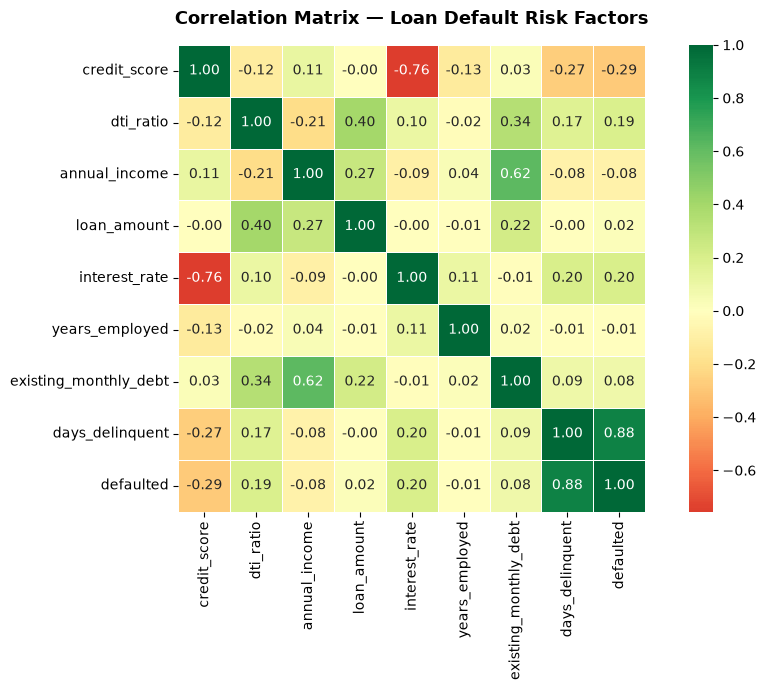

In [79]:
corr_cols = ['credit_score', 'dti_ratio', 'annual_income',
             'loan_amount', 'interest_rate', 'years_employed',
             'existing_monthly_debt', 'days_delinquent', 'defaulted']

plt.figure(figsize=(10, 7))
sns.heatmap(
    df[corr_cols].corr(),
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    linewidths=0.5, square=True,
    annot_kws={'size': 10}
)
plt.title('Correlation Matrix — Loan Default Risk Factors',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/chart5_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 📊 Chart 5 — Correlation Matrix Insight

**Correlations with Default (ranked by strength):**

| Variable | Correlation | Direction |
|---|---|---|
| days_delinquent | 0.88 | 🔴 Strong Positive |
| interest_rate | 0.20 | 🟠 Moderate Positive |
| dti_ratio | 0.19 | 🟠 Moderate Positive |
| existing_monthly_debt | 0.08 | Weak Positive |
| loan_amount | 0.02 | ⚪ Negligible |
| years_employed | -0.01 | ⚪ Negligible |
| annual_income | -0.08 | Weak Negative |
| credit_score | -0.29 | 🟢 Moderate Negative |

**Key Finding 1 — days_delinquent is the #1 predictor (0.88):**
Near-perfect correlation with default. Borrowers showing early 
payment delays are almost certain to default. This variable should 
power a real-time early warning system to flag at-risk accounts 
before they formally default.

**Key Finding 2 — credit_score vs interest_rate paradox (-0.76):**
Credit score and interest rate are strongly inversely correlated. 
Low-score borrowers are charged higher rates — but those higher 
rates correlate with more defaults (+0.20). The current pricing 
model is identifying risk correctly but not mitigating it.

**Key Finding 3 — loan amount is irrelevant (0.02):**
Loan size has virtually zero correlation with default. This 
confirms Chart 3 findings — borrower profile matters far 
more than loan size. Underwriting focus should be on WHO 
is borrowing, not HOW MUCH they borrow.

**Recommendation:**
Build an early delinquency alert system — flag any borrower 
missing even one payment for immediate intervention. The 0.88 
correlation means early action could prevent the majority of defaults.